Casos de aplicación: Promoción de nuevos productos
===

---

## Definición del problema real

SURA desea conocer y explorar el potencial de sus clientes en términos comerciales, es decir, implementar estrategias para diversificar el portafolio de productos de cada cliente, tomando como premisa la atención personalizada a cada cliente de acuerdo con sus características y necesidades específicas. El problema consiste en determinar qué productos se les debe recomendar a un cliente teniendo en cuenta las compras que ha realizado hasta el momento.

## Definición del problema en términos de los datos

Se tiene una muestra de 2000 observaciones. Cada registro contiene 15 atributos que caracterizan la transacción de un cliente y las polizas que cada cliente ha comprado hasta el momento. La información proviene de las bases de datos de cada tipo de poliza. A continuación se describen los atributos disponibles:

        -------------------------------------------------------------------------------------------------------------------------------------------------
       | Variables	               Descripcion						                    Valores válidos                                              |
        ------------------------------------------------------------------------------------------------------------------------------------------------- 
       | Fecha_Nacimiento	        Fecha nacimiento cliente 				              Fechas lógicas                                               |
       | Edad_Cliente			    Edad del cliente en este momento del tiempo		    Numeros positivos que concuerden con la fecha de nacimiento  |
       | Nombre_Agente			   Nombre del asesor del cliente				          Cadenas de caracteres                                        |
       | POLIZA_AUTOS			    El cliente cuenta con poliza de Autos			      SI o NO                                                      |
       | POLIZA_SOAT			     El cliente cuenta con SOAT				             SI o NO                                                      |
       | POLIZA_VIDAINDIVIDUAL	   El cliente cuenta con la poliza de Vida Individual	 SI o NO                                                      |
       | POLIZA_SALUD			    El cliente cuenta con poliza de Salud			      SI o NO                                                      |
       | POLIZA_HOGAR			    El cliente cuenta con poliza de Hogar			      SI o NO                                                      |
       | POLIZA_VIDAGRUPO		    El cliente cuenta con poliza de Vida Grupo		     SI o NO                                                      |
       | POLIZA_MASVIDA			  El cliente cuenta con poliza de Mas Vida		       SI o NO                                                      |
       | POLIZA_ACCIDENTESPERSONALES El cliente cuenta con poliza de Accidentes personales  SI o NO                                                      |
       | POLIZA_CUMPLIMIENTO		 El cliente cuenta con poliza de Cumplimiento		   SI o NO                                                      |
       | POLIZA_INCENDIO			 El cliente cuenta con poliza de Incendio		       SI o NO                                                      |
       | POLIZA_JUVENIL			  El cliente cuenta con poliza de Juvenil			    SI o NO                                                      |
       | POLIZA_EXEQUIAL			 El cliente cuenta con poliza de Exequial		       SI o NO                                                      |
        -------------------------------------------------------------------------------------------------------------------------------------------------

## Exploración

In [1]:
##
## Se realiza la lectura de los datos
##

x <- read.csv(file = 'Clientes.csv',   # nombre del archivo
              header = TRUE,           # nombres de columnas
              sep = ";",               # separador de campos
              dec = ",",               # separador de decimales
              na.strings="-1",         # valores faltantes
              row.names=NULL,          # ignore el identificador de campos
              stringsAsFactors = FALSE)# toma las variables categoricas como campos de texto
head(x)

Fecha_Nacimiento,Edad_Cliente,Nombre_Agente,POLIZA_AUTOS,POLIZA_SOAT,POLIZA_VIDAINDIVIDUAL,POLIZA_SALUD,POLIZA_HOGAR,POLIZA_VIDAGRUPO,POLIZA_MASVIDA,POLIZA_ACCIDENTESPERSONALES,POLIZA_CUMPLIMIENTO,POLIZA_INCENDIO,POLIZA_JUVENIL,POLIZA_EXEQUIAL
3/10/1992,26,AGENCIA DE SEGUROS Y MEDICINA PREPAGADA VENSALUD LTDA,NO,NO,NO,SI,NO,NO,NO,NO,NO,NO,NO,NO
1/01/1970,49,JARDINE LLOYD THOMPSON VALENCIA & IRAGORRI CORREDORES DE SEGUROS S.A.,NO,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO,NO
8/06/1968,50,SERVICIOS FINANCIEROS S.A. SERFINANSA COMPAÑIA DE FINANCIAMIENTO,NO,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO,NO
21/01/1953,66,AON RISK SERVICES COLOMBIA S.A.,NO,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO,NO
14/06/1954,64,WILLIS TOWERS WATSON COLOMBIA CORREDORES DE SEGUROS SA,SI,NO,NO,NO,NO,SI,NO,NO,NO,NO,NO,NO
12/07/1984,34,Sin Información,NO,NO,SI,NO,NO,NO,SI,NO,NO,NO,NO,SI


In [2]:
str(x)

'data.frame':	2000 obs. of  15 variables:
 $ Fecha_Nacimiento           : chr  "3/10/1992" "1/01/1970" "8/06/1968" "21/01/1953" ...
 $ Edad_Cliente               : int  26 49 50 66 64 34 24 24 34 36 ...
 $ Nombre_Agente              : chr  "AGENCIA DE SEGUROS Y MEDICINA PREPAGADA VENSALUD LTDA" "JARDINE LLOYD THOMPSON VALENCIA & IRAGORRI CORREDORES DE SEGUROS S.A." "SERVICIOS FINANCIEROS S.A. SERFINANSA COMPAÑIA DE FINANCIAMIENTO" "AON RISK SERVICES COLOMBIA S.A." ...
 $ POLIZA_AUTOS               : chr  "NO" "NO" "NO" "NO" ...
 $ POLIZA_SOAT                : chr  "NO" "NO" "NO" "NO" ...
 $ POLIZA_VIDAINDIVIDUAL      : chr  "NO" "NO" "NO" "NO" ...
 $ POLIZA_SALUD               : chr  "SI" "NO" "NO" "NO" ...
 $ POLIZA_HOGAR               : chr  "NO" "NO" "NO" "NO" ...
 $ POLIZA_VIDAGRUPO           : chr  "NO" "SI" "SI" "SI" ...
 $ POLIZA_MASVIDA             : chr  "NO" "NO" "NO" "NO" ...
 $ POLIZA_ACCIDENTESPERSONALES: chr  "NO" "NO" "NO" "NO" ...
 $ POLIZA_CUMPLIMIENTO        : chr  "N

Observe que están presentes algunas variables que a simple vista no guardan relación con las decisiones de compra del cliente, como la fecha de nacimiento y el nombre del agente. Por su parte, en este caso, la edad del cliente podría reemplazar la información que brinda la fecha de nacimiento. 

Se pasa de 2000 observaciones a 1669 debido a que los registros iniciales contenian información faltante en los campos de interés.

In [3]:
data <- x[,c(-1,-3)]              # Se incluyen solo las variables referentes a la existencia o no de las polizas por cliente
data <-  data[complete.cases(data),] # Se eliminan los casos con datos faltantes
colnames(data) <- c("EDAD","AUTOS","SOAT","VIDA INDIVIDUAL","SALUD","HOGAR","VIDAGRUPO","MASVIDA","ACCI. PERSONALES","CUMPLIMIENTO",
                    "INCENDIO","JUVENIL", "EXEQUIAL")
str(data)

'data.frame':	1669 obs. of  13 variables:
 $ EDAD            : int  26 49 50 66 64 34 24 24 34 36 ...
 $ AUTOS           : chr  "NO" "NO" "NO" "NO" ...
 $ SOAT            : chr  "NO" "NO" "NO" "NO" ...
 $ VIDA INDIVIDUAL : chr  "NO" "NO" "NO" "NO" ...
 $ SALUD           : chr  "SI" "NO" "NO" "NO" ...
 $ HOGAR           : chr  "NO" "NO" "NO" "NO" ...
 $ VIDAGRUPO       : chr  "NO" "SI" "SI" "SI" ...
 $ MASVIDA         : chr  "NO" "NO" "NO" "NO" ...
 $ ACCI. PERSONALES: chr  "NO" "NO" "NO" "NO" ...
 $ CUMPLIMIENTO    : chr  "NO" "NO" "NO" "NO" ...
 $ INCENDIO        : chr  "NO" "NO" "NO" "NO" ...
 $ JUVENIL         : chr  "NO" "NO" "NO" "NO" ...
 $ EXEQUIAL        : chr  "NO" "NO" "NO" "NO" ...


La siguiente gráfica refleja que existen algunos clientes que no poseen ninguna póliza, dichos son registros no aportan conocimiento sobre el perfil de compra del cliente y denota que son campos posiblemente corruptos en la base de datos. De igual forma, existen clientes con edad cero que no representan mayor conocimiento al modelo ya que no se consideran agentes que toman decisiones.

In [4]:
data$num_polizas <- apply(data[,c(-1)],1,function(x) sum(x == "SI")) # Se crea una columna nueva al dataframe con el número de polizas que tiene un cliente
table(data$num_polizas)


   0    1    2    3    4    6 
 158 1239  238   29    4    1 

En el siguiente gráfico se muestra el comportamiento del número de polizas por persona, antes de eliminar los registros corruptos y luego del proceso de limpieza.

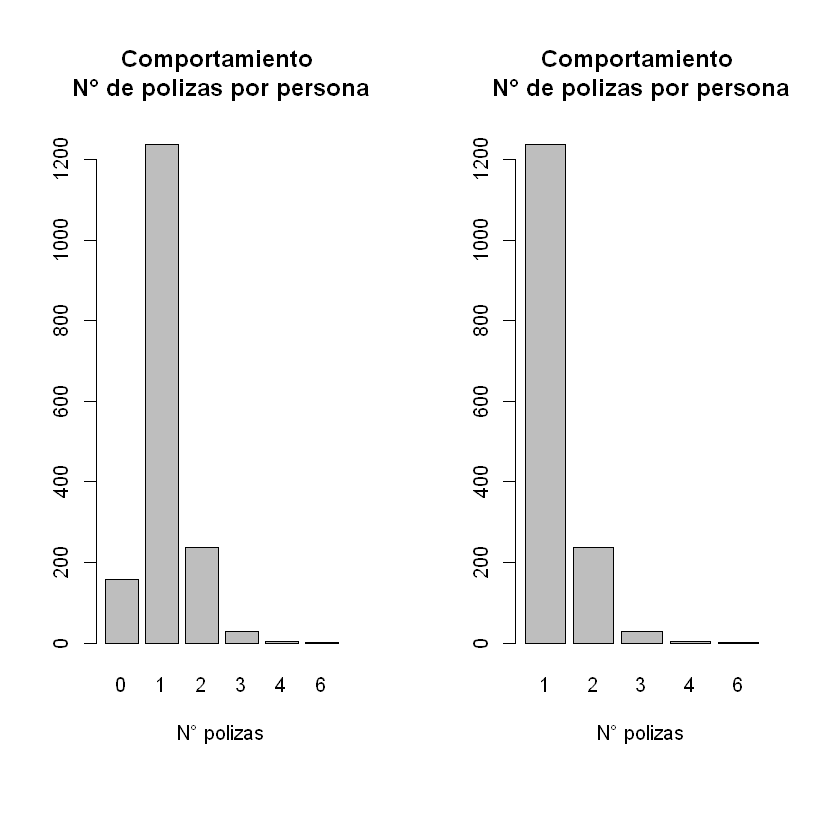

In [5]:
par(mar=c(8,4,6,3), mfrow = c(1.5, 2))
barplot(table(data$num_polizas), main= "Comportamiento 
N° de polizas por persona", xlab="N° polizas")
data <- data[!data$num_polizas== 0,]
barplot(table(data$num_polizas), main= "Comportamiento 
N° de polizas por persona", xlab="N° polizas")  

La mayoría de los clientes cuentan con una poliza, lo cual indica que un posible modelo de reglas de recomendación puede priorizar a las personas de un producto más que a las de una cantidad mayor de polizas, esto beneficiaría a la compañía en términos del negocio ya que abarcaría a la mayor cantidad de clientes.

In [6]:
str(data) ## La cantidad de registros para la muestra se reduce a 1511 transacciones

'data.frame':	1511 obs. of  14 variables:
 $ EDAD            : int  26 49 50 66 64 34 24 24 34 36 ...
 $ AUTOS           : chr  "NO" "NO" "NO" "NO" ...
 $ SOAT            : chr  "NO" "NO" "NO" "NO" ...
 $ VIDA INDIVIDUAL : chr  "NO" "NO" "NO" "NO" ...
 $ SALUD           : chr  "SI" "NO" "NO" "NO" ...
 $ HOGAR           : chr  "NO" "NO" "NO" "NO" ...
 $ VIDAGRUPO       : chr  "NO" "SI" "SI" "SI" ...
 $ MASVIDA         : chr  "NO" "NO" "NO" "NO" ...
 $ ACCI. PERSONALES: chr  "NO" "NO" "NO" "NO" ...
 $ CUMPLIMIENTO    : chr  "NO" "NO" "NO" "NO" ...
 $ INCENDIO        : chr  "NO" "NO" "NO" "NO" ...
 $ JUVENIL         : chr  "NO" "NO" "NO" "NO" ...
 $ EXEQUIAL        : chr  "NO" "NO" "NO" "NO" ...
 $ num_polizas     : int  1 1 1 1 2 3 2 1 2 1 ...


El siguiente gráfico refleja el número de clientes que poseen o no poseen cada tipo de póliza. La poliza más popular es la de Vida Grupo y la que menos poseen los clientes de la muestra es la de cumplimiento, mientras que de la juvenil no se presenta ningún caso.

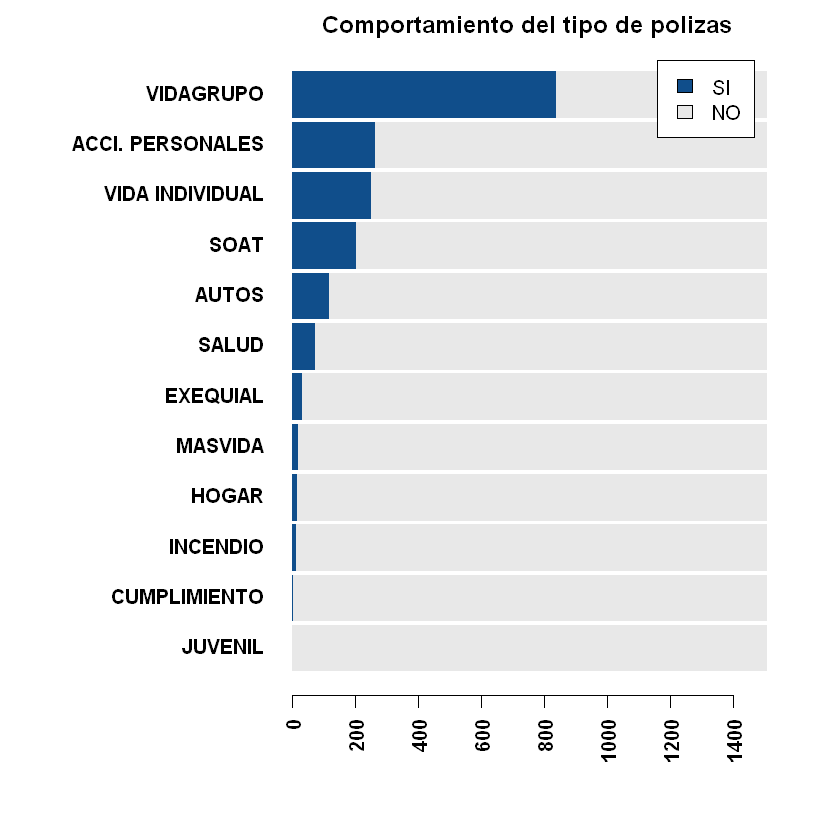

In [7]:
data_plot <- as.data.frame(t(data[,c(-1,-14)]))
data_plot$si <- rowSums(data_plot=="SI")
data_plot$no <- rowSums(data_plot=="NO")
data_plot <- data_plot[order(data_plot$si,decreasing = FALSE),]
data_plot <- t(data_plot[,c("si","no")])

par(las=2)
par(mar=c(6,12,2,3), mfrow = c(1, 1)) # ajustes en el tamaño y posición de los ejes y figura 
barplot(data_plot,space=0.08,font.axis=2,main='Comportamiento del tipo de polizas',col=c("dodgerblue4","gray91"),
        legend = c("SI","NO"), horiz = TRUE,border = c(NA, NA, NA)) 

In [8]:
##
## Los clientes de la muestra tienen una edad promedio de 41 años. 
##
summary(data$EDAD)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   32.00   41.00   42.23   52.00   91.00 

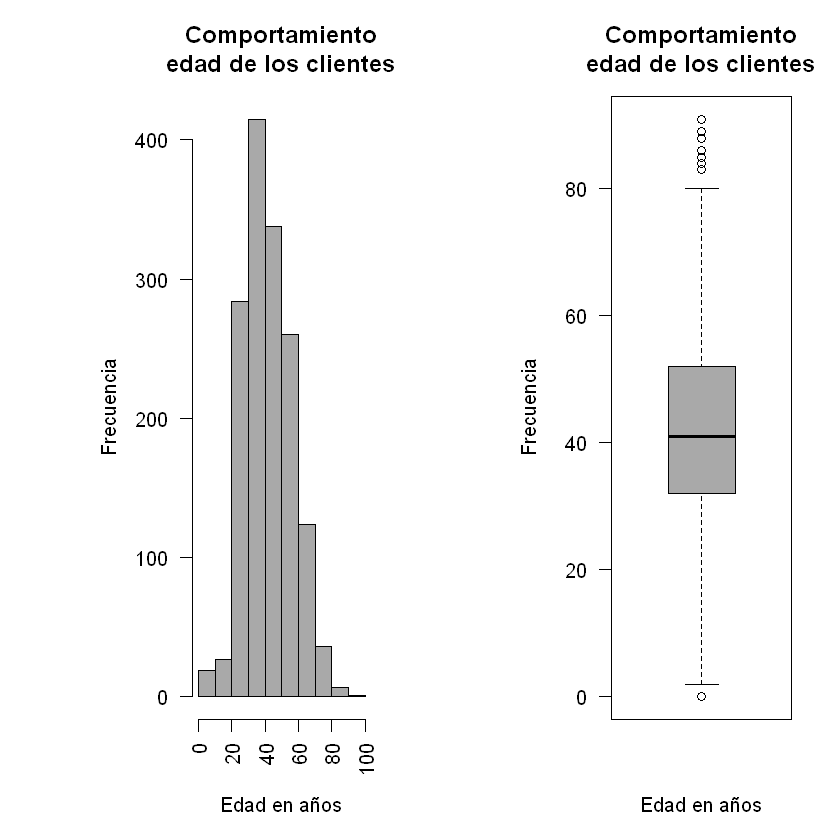

In [9]:
par(las=2) # labels perpendiculares al eje
par(mar=c(5,8,4,2), mfrow = c(1, 2)) # ajustes en el tamaño y posición de los ejes y figura 
hist(data$EDAD, main="Comportamiento
edad de los clientes", xlab="Edad en años", ylab="Frecuencia", col="darkgrey")
boxplot(data$EDAD,main="Comportamiento
edad de los clientes", xlab="Edad en años", ylab="Frecuencia", col="darkgrey")

## Metodología 
Para resolver el problema se tendrá en cuenta el algoritmo Apriori.

## Apriori

La mayoría  de la información disponible se refiere a las transacciones del cliente y no a su perfil de compra, por ello se opta inicialmente por un sistema de recomendación basado en las compras que ha realizado un cliente, tomando así solo las últimas 12 variables.

In [10]:
summary(data)

      EDAD          AUTOS               SOAT           VIDA INDIVIDUAL   
 Min.   : 0.00   Length:1511        Length:1511        Length:1511       
 1st Qu.:32.00   Class :character   Class :character   Class :character  
 Median :41.00   Mode  :character   Mode  :character   Mode  :character  
 Mean   :42.23                                                           
 3rd Qu.:52.00                                                           
 Max.   :91.00                                                           
    SALUD              HOGAR            VIDAGRUPO           MASVIDA         
 Length:1511        Length:1511        Length:1511        Length:1511       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                    

Se cambian los valores de *SI* por el nombre de la poliza y los *NO* por espacios vacíos dentro de la tabla para que el formato de los datos esté en términos de transacciones.

In [11]:
##
## Se itera sobre las columnas válidas 
## 
for (i in seq(2,13)){
    name <- colnames(data)[i]
    data[i][data[i]=="SI"] <-  name
    data[i][data[i]=="NO"] <- ""
}

In [12]:
## 
## Se exportan las transacciones validas a un archivo .csv
##
write.csv(data[,c(-1,-14)], file = "data.csv", na = "",row.names = FALSE)

In [13]:
##  
## Se carga la información de las transacciones
## 

library(arules)
products <- read.transactions('data.csv', sep=',')
products <- products[-1,]
products

Loading required package: Matrix

Attaching package: 'arules'

The following objects are masked from 'package:base':

    abbreviate, write



transactions in sparse format with
 1511 transactions (rows) and
 12 items (columns)

In [14]:
##
## Se visualizan los items comprados en las primeras
## cinco transacciones (filas del archivo)
##
inspect(products[6:10])

    items                             
[1] {EXEQUIAL,MASVIDA,VIDA INDIVIDUAL}
[2] {ACCI. PERSONALES,VIDAGRUPO}      
[3] {VIDAGRUPO}                       
[4] {ACCI. PERSONALES,SOAT}           
[5] {VIDAGRUPO}                       


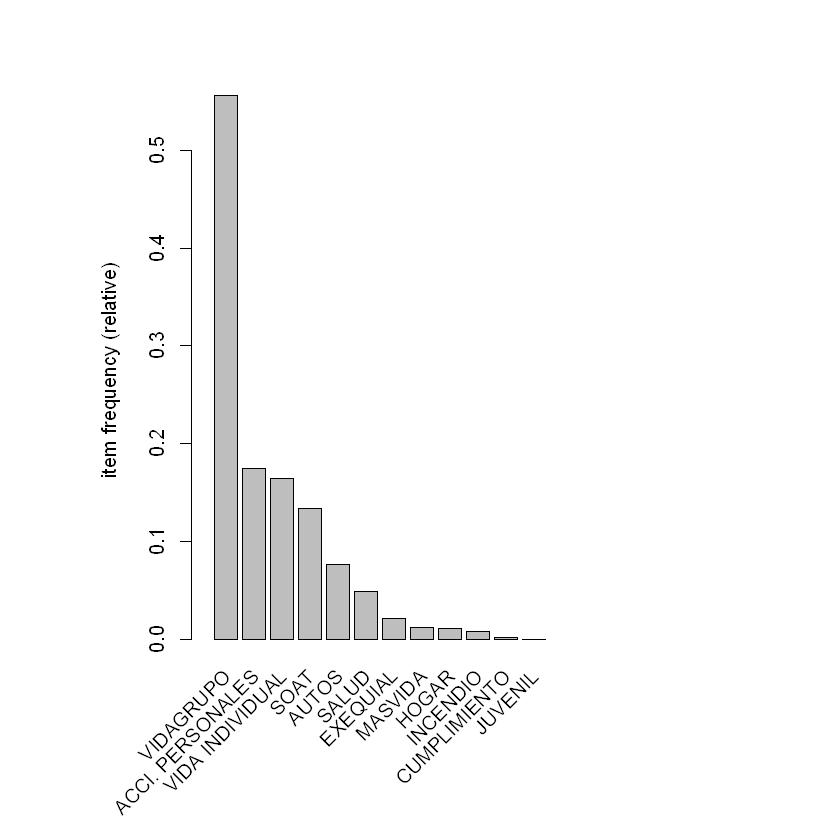

In [15]:
par(mar=c(5,8,4,2))
itemFrequencyPlot(products, topN=20)

## Entrenamiento del modelo

El soporte y la confianza del modelo lo define el experto de negocio ya que deben ir acorde al objetivo del problema real. En este caso, se escogerá una confianza mínima de 60%, un soporte mínimo de 1% y las reglas deben contener mínimo 2 items.

In [16]:
## 
## De acuerdo con el soporte, el item debería aparecer en un mínimo de 20 transacciones
##
rules <- apriori(products, parameter = list(support = 0.01, 
                                            confidence = 0.6, 
                                            minlen = 2))
rules

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.6    0.1    1 none FALSE            TRUE       5    0.01      2
 maxlen target   ext
     10  rules FALSE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 15 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[11 item(s), 1511 transaction(s)] done [0.00s].
sorting and recoding items ... [9 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 done [0.00s].
writing ... [2 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


set of 2 rules 

In [17]:
summary(rules)

set of 2 rules

rule length distribution (lhs + rhs):sizes
2 
2 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      2       2       2       2       2       2 

summary of quality measures:
    support          confidence          lift           count      
 Min.   :0.01456   Min.   :0.6364   Min.   :1.145   Min.   : 22.0  
 1st Qu.:0.03872   1st Qu.:0.6547   1st Qu.:1.935   1st Qu.: 58.5  
 Median :0.06287   Median :0.6730   Median :2.726   Median : 95.0  
 Mean   :0.06287   Mean   :0.6730   Mean   :2.726   Mean   : 95.0  
 3rd Qu.:0.08703   3rd Qu.:0.6913   3rd Qu.:3.516   3rd Qu.:131.5  
 Max.   :0.11118   Max.   :0.7097   Max.   :4.307   Max.   :168.0  

mining info:
     data ntransactions support confidence
 products          1511    0.01        0.6

In [18]:
inspect(rules)

    lhs                   rhs               support    confidence lift    
[1] {EXEQUIAL}         => {VIDA INDIVIDUAL} 0.01455989 0.7096774  4.306516
[2] {ACCI. PERSONALES} => {VIDAGRUPO}       0.11118465 0.6363636  1.144697
    count
[1]  22  
[2] 168  


In [19]:
autos <- subset(products, items %in% "SOAT")
inspect(autos)

      items                                            
[1]   {ACCI. PERSONALES,SOAT}                          
[2]   {SOAT,VIDA INDIVIDUAL}                           
[3]   {SOAT,VIDA INDIVIDUAL}                           
[4]   {SOAT}                                           
[5]   {SOAT}                                           
[6]   {SOAT}                                           
[7]   {SOAT}                                           
[8]   {SOAT}                                           
[9]   {SOAT}                                           
[10]  {SOAT}                                           
[11]  {SOAT}                                           
[12]  {SOAT}                                           
[13]  {SOAT}                                           
[14]  {ACCI. PERSONALES,SOAT,VIDA INDIVIDUAL}          
[15]  {SOAT}                                           
[16]  {SOAT}                                           
[17]  {SOAT}                                    

De acuerdo con el algoritmo Apriori, se escogen dos reglas de asociación que cumplen con los parámetros mínimos tablecidos. Con una probabilidad aproximada de 71%, un cliente que tenga poliza exequial podría estar interesado en comprar una poliza de vida individual. Analogamente, un cliente que haya comprado una poliza para accidentes personales podría estar interesado en un seguro de vida con una probabilidad del 63%.

In [20]:
inspect(sort(rules, by = "confidence"))

    lhs                   rhs               support    confidence lift    
[1] {EXEQUIAL}         => {VIDA INDIVIDUAL} 0.01455989 0.7096774  4.306516
[2] {ACCI. PERSONALES} => {VIDAGRUPO}       0.11118465 0.6363636  1.144697
    count
[1]  22  
[2] 168  


---

### Conclusiones y/o Recomendaciones

* Con una muestra mayor de transacciones, se podrían encontrar relaciones entre otro tipo de polizas altamente frecuentes como SOAT y Salud.

---